In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Chemin du fichier dans Drive
file_path = "/content/drive/MyDrive/SousFact.csv"

# Charger le fichier dans un DataFrame pandas
df = pd.read_csv(file_path)

# Afficher les premières lignes
df.head()

,CustomerID,Product_ID,AmountCustomer,SupplierID,InvoiceID,PayementDate,AmountPaidSupplier,DueDate,InvoiceAmount,Revenu,Investissement_dans_les_Actifs,Annee,DisputeID,DisputeDate,ResolutionDate,AddressCustomer,DiscountOffered,DiscountUsed
0,CUST00928,P100400,660,SP1078,INV03261,01/05/2024,4742.76,2021-05-10,3900.00,7.979323e+09,3.189714e+08,2024,DS03261,2020-01-20,2024-11-16,"Adresse du client 928, Ville 827, Pays",209.77,166.80
1,CUST05131,P100036,4798,SP1149,INV8151,07/02/2020,4008.94,2017-05-06,5502.76,6.143543e+09,2.443343e+08,2020,NaN,NaN,NaN,"Adresse du client 5131, Ville 214, Pays",134.63,95.03
2,CUST02809,P100510,3130,SP1107,INV03270,01/25/2023,540.72,2020-07-06,1549.00,6.028046e+09,1.987448e+08,2023,DS03270,2021-06-08,2024-10-30,"Adresse du client 2809, Ville 638, Pays",424.83,398.47
3,CUST06116,P100451,2159,SP1091,INV03391,05/30/2023,3766.52,2021-12-30,1505.00,6.028046e+09,1.987448e+08,2023,DS03391,2023-12-08,2024-12-11,"Adresse du client 6116, Ville 250, Pays",437.94,176.55
4,CUST00090,PROD067,2841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,"Adresse du client 90, Ville 641, Pays",0.00,0.00


In [16]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# ➕ Création de la variable cible : Délai de paiement
df['PayementDate'] = pd.to_datetime(df['PayementDate'], errors='coerce')
df['DueDate'] = pd.to_datetime(df['DueDate'], errors='coerce')
df['Delai_Paiement'] = (df['PayementDate'] - df['DueDate']).dt.days

# 🧹 Suppression des lignes avec valeurs manquantes
df = df.dropna(subset=['Delai_Paiement'])

# 🎯 Features & Target
X = df[[ 'InvoiceAmount', 'DiscountOffered', 'DiscountUsed']]
y = df['Delai_Paiement']

# 🔀 Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📈 Modèle
model = XGBRegressor()
model.fit(X_train, y_train)

# 🎯 Prédictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 📊 Évaluation sur train
print("📘 Performances sur TRAIN :")
print("✅ RMSE :", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2), "jours")
print("✅ MAE  :", round(mean_absolute_error(y_train, y_train_pred), 2), "jours")
print("✅ R²   :", round(r2_score(y_train, y_train_pred), 4))

# 📊 Évaluation sur test
print("\n📕 Performances sur TEST :")
print("✅ RMSE :", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2), "jours")
print("✅ R²   :", round(r2_score(y_test, y_test_pred), 4))


📘 Performances sur TRAIN :
✅ RMSE : 119.38 jours
✅ MAE  : 12.56 jours
✅ R²   : 0.9936

📕 Performances sur TEST :
✅ RMSE : 123.27 jours
✅ R²   : 0.9934


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


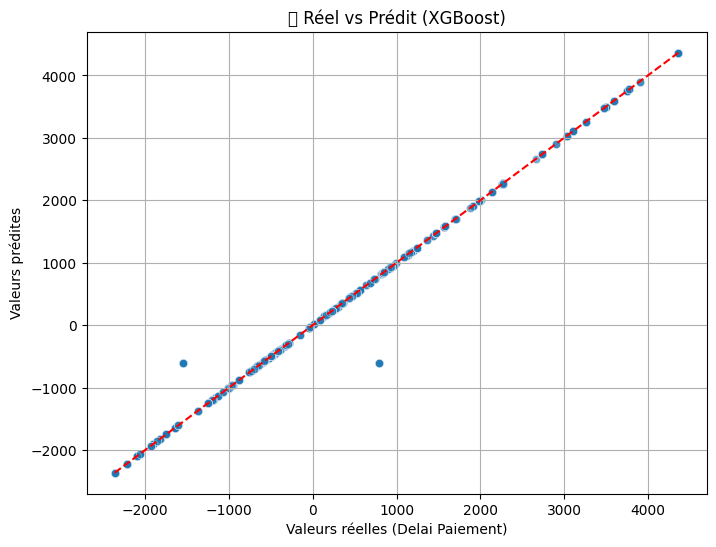

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


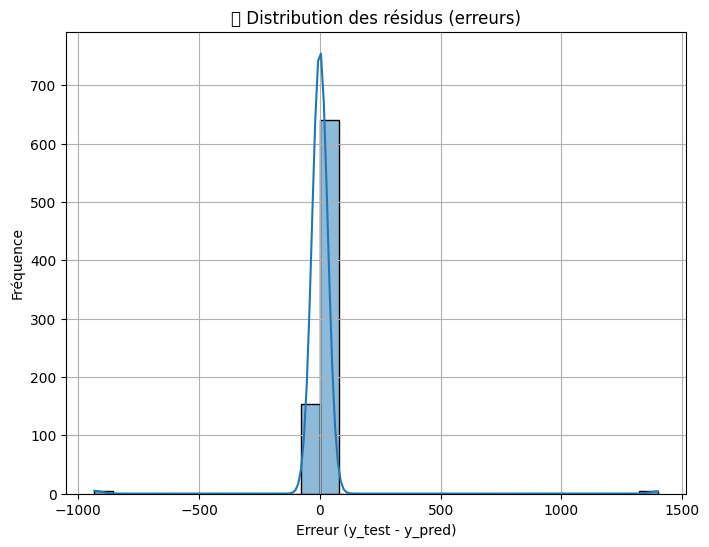

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🎯 1. Courbe des valeurs réelles vs prédites (sur test)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Valeurs réelles (Delai Paiement)")
plt.ylabel("Valeurs prédites")
plt.title("🎯 Réel vs Prédit (XGBoost)")
plt.grid(True)
plt.show()

# 📉 2. Distribution des erreurs (résidus)
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("🔍 Distribution des résidus (erreurs)")
plt.xlabel("Erreur (y_test - y_pred)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# ➕ Création de la variable cible : Délai de paiement
df['PayementDate'] = pd.to_datetime(df['PayementDate'], errors='coerce')
df['DueDate'] = pd.to_datetime(df['DueDate'], errors='coerce')
df['Delai_Paiement'] = (df['PayementDate'] - df['DueDate']).dt.days

# 🧹 Suppression des lignes avec valeurs manquantes
df = df.dropna(subset=['Delai_Paiement'])

# 🎯 Features & Target
X = df[['InvoiceAmount', 'DiscountOffered', 'DiscountUsed']]
y = df['Delai_Paiement']

# 🔀 Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📉 Modèle : Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 🎯 Prédictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# 📊 Évaluation sur train
print("📘 Performances sur TRAIN (Linear Regression) :")
print("✅ RMSE :", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2), "jours")
print("✅ R²   :", round(r2_score(y_train, y_train_pred), 4))

# 📊 Évaluation sur test
print("\n📕 Performances sur TEST (Linear Regression) :")
print("✅ RMSE :", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2), "jours")
print("✅ R²   :", round(r2_score(y_test, y_test_pred), 4))


📘 Performances sur TRAIN (Linear Regression) :
✅ RMSE : 1318.98 jours
✅ R²   : 0.2219

📕 Performances sur TEST (Linear Regression) :
✅ RMSE : 1326.29 jours
✅ R²   : 0.2317


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


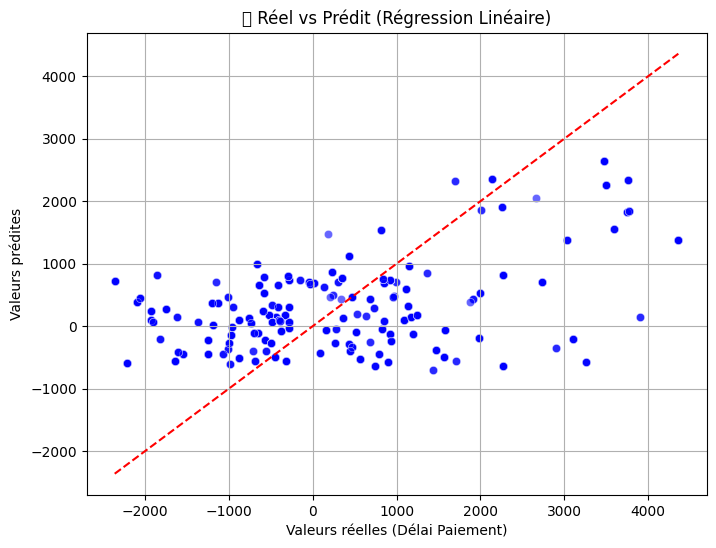

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


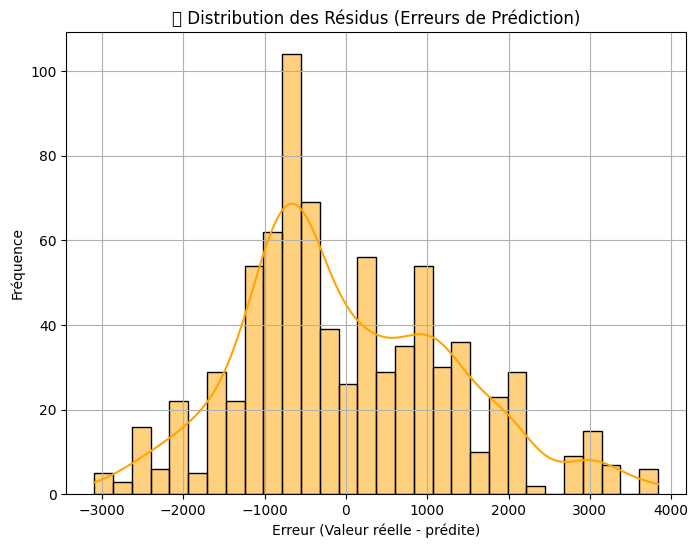

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🎯 1. Réel vs Prédit (sur test set)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonale parfaite
plt.xlabel("Valeurs réelles (Délai Paiement)")
plt.ylabel("Valeurs prédites")
plt.title("🎯 Réel vs Prédit (Régression Linéaire)")
plt.grid(True)
plt.show()

# 📉 2. Distribution des erreurs (résidus)
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title("🔍 Distribution des Résidus (Erreurs de Prédiction)")
plt.xlabel("Erreur (Valeur réelle - prédite)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


In [12]:
afrom sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# ➕ Création de la variable cible : Délai de paiement
df['PayementDate'] = pd.to_datetime(df['PayementDate'], errors='coerce')
df['DueDate'] = pd.to_datetime(df['DueDate'], errors='coerce')
df['Delai_Paiement'] = (df['PayementDate'] - df['DueDate']).dt.days

# 🧹 Suppression des lignes avec valeurs manquantes
df = df.dropna(subset=['Delai_Paiement'])

# 🎯 Features & Target
X = df[['InvoiceAmount', 'DiscountOffered', 'DiscountUsed']]
y = df['Delai_Paiement']

# 🔀 Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🌲 Modèle Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 📊 Prédictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 📘 Évaluation sur TRAIN
print("📘 Performances sur TRAIN (Random Forest) :")
print("✅ RMSE :", round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2), "jours")
print("✅ MAE  :", round(mean_absolute_error(y_train, y_train_pred), 2), "jours")
print("✅ R²   :", round(r2_score(y_train, y_train_pred), 4))

# 📕 Évaluation sur TEST
print("\n📕 Performances sur TEST (Random Forest) :")
print("✅ RMSE :", round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2), "jours")
print("✅ R²   :", round(r2_score(y_test, y_test_pred), 4))


📘 Performances sur TRAIN (Random Forest) :
✅ RMSE : 119.39 jours
✅ MAE  : 12.19 jours
✅ R²   : 0.9936

📕 Performances sur TEST (Random Forest) :
✅ RMSE : 123.43 jours
✅ R²   : 0.9933


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


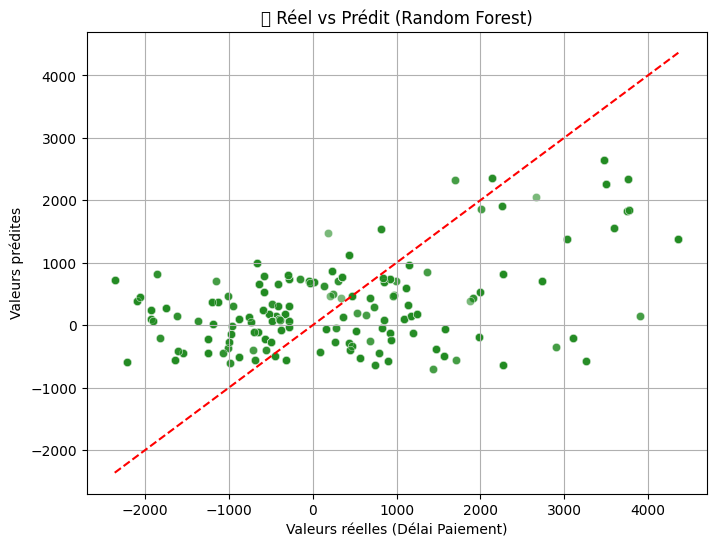

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


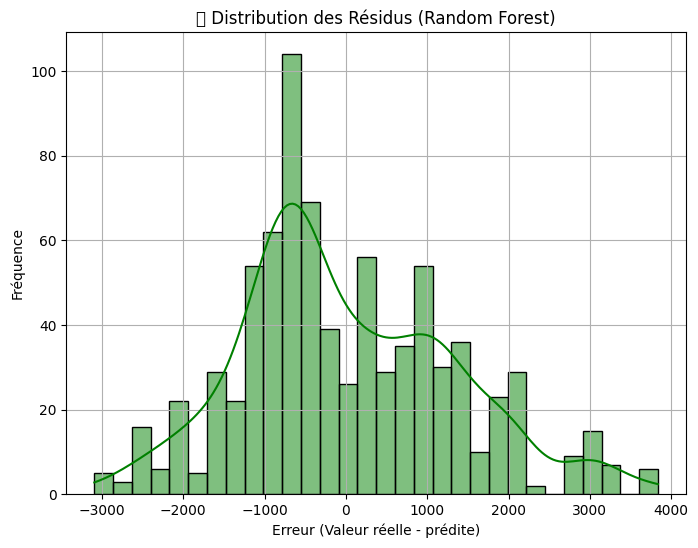

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🎯 1. Réel vs Prédit (sur test set)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, color='forestgreen', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonale parfaite
plt.xlabel("Valeurs réelles (Délai Paiement)")
plt.ylabel("Valeurs prédites")
plt.title("🎯 Réel vs Prédit (Random Forest)")
plt.grid(True)
plt.show()

# 📉 2. Distribution des erreurs (résidus)
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='green')
plt.title("🔍 Distribution des Résidus (Random Forest)")
plt.xlabel("Erreur (Valeur réelle - prédite)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()
